# Programma che esegue il fit per 3 componenti (SVD):

## Programma di fit:

Per prima cosa è necessario andare a creare la matrice ridotta con sklearn da cui, passandogli il n° di componenti che vuoi, puoi ricavarti i nuovi vettori che saranno:
- U'= $U \cdot S$;
- V'= $V^T$

In [1]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import pandas as pd
import os
from pathlib import Path


base_dir = Path().resolve()

file_puliti = base_dir / "dati_puliti.csv"
file_matrice = base_dir / "matrice_con_t.dat"

df = pd.read_csv(file_puliti, sep="\t", header=None)
df_original = pd.read_csv(file_matrice, sep=",", header=None)

print("File caricati correttamente.")


# Crea un array con le lunghezze d'onda
l_array = df_original.iloc[1:, 0].values
l_array = sorted([float(x.replace(',', '.')) for x in l_array])
l_array = np.array(l_array) # Converti in array numpy x indice


# Funzione per ridurre con SVD
def riduci_svd(matrice, n_componenti):
    svd = TruncatedSVD(n_components=n_componenti)
    U_prime = svd.fit_transform(matrice)  # U'=U*S, fitta il modello cioè calcola comp princ (n_spettri, n_componenti)
    V_prime = svd.components_             # V' (n_componenti, n_colonne (T)) 
    S = svd.singular_values_                   # per il monte carlo serve S
    
    return U_prime, V_prime, S
    
# Applica la funzione
U_prime, V_prime, S = riduci_svd(df, 3)


V_file = Path("V_prime.csv")
U_file = Path("U_prime.csv")

pd.DataFrame(V_prime).to_csv(V_file, sep="\t", index=False, header=False)

if not U_file.exists():
    pd.DataFrame(U_prime).to_csv(U_file, sep="\t", index=False, header=False)

if not V_file.exists():
    pd.DataFrame(V_prime).to_csv(V_file, sep="\t", index=False, header=False)


# Vediamo come è ordinato l_array
print("Lunghezze d'onda ordinate:")
print(l_array)

File caricati correttamente.
Lunghezze d'onda ordinate:
[220.  220.5 221.  221.5 222.  222.5 223.  223.5 224.  224.5 225.  225.5
 226.  226.5 227.  227.5 228.  228.5 229.  229.5 230.  230.5 231.  231.5
 232.  232.5 233.  233.5 234.  234.5 235.  235.5 236.  236.5 237.  237.5
 238.  238.5 239.  239.5 240.  240.5 241.  241.5 242.  242.5 243.  243.5
 244.  244.5 245.  245.5 246.  246.5 247.  247.5 248.  248.5 249.  249.5
 250.  250.5 251.  251.5 252.  252.5 253.  253.5 254.  254.5 255.  255.5
 256.  256.5 257.  257.5 258.  258.5 259.  259.5 260.  260.5 261.  261.5
 262.  262.5 263.  263.5 264.  264.5 265.  265.5 266.  266.5 267.  267.5
 268.  268.5 269.  269.5 270.  270.5 271.  271.5 272.  272.5 273.  273.5
 274.  274.5 275.  275.5 276.  276.5 277.  277.5 278.  278.5 279.  279.5
 280.  280.5 281.  281.5 282.  282.5 283.  283.5 284.  284.5 285.  285.5
 286.  286.5 287.  287.5 288.  288.5 289.  289.5 290.  290.5 291.  291.5
 292.  292.5 293.  293.5 294.  294.5 295.  295.5 296.  296.5 297.  2

Ora al fine di fare un fit globale, visto che i parametri in gioco sono molti è necessario fare delle consideraizoni.
L'obiettivo è quello di fare un fit globale delle prime n componenti $V'_i$ con le funzioni $f_i(x)$;
- DoveLa funzione fitted \( f_i(T) \) per ciascuna componente SVD è definita come:

$$
f_i(T) = \sum_{j=1}^{3} C_{ij} \cdot M_j(T)
$$

dove:
- $ i = 1, 2, 3 $ rappresenta le componenti principali $ V'_1, V'_2, V'_3 $;
- $ j = 1, 2, 3 $ rappresenta gli stati conformazionali:
  - $ M_1(T) $: stato Folded
  - $ M_2(T) $: stato Intermedio
  - $ M_3(T) $: stato Unfolded
- $ C_{ij} $ sono i coefficienti di pesatura per ciascuna componente

e, di nuovo, $M_i(x)$ sono le equazioni di Van't Hoff, definite in questo modo:
1) $ M_{1} = \frac {1}{denom} $
2) $ M_{2} = \frac {A}{denom}$
3) $ M_{3} = \frac {A \cdot B}{denom}$

ed: A,B definiti:

1) $ A = exp(- \frac {\Delta H_{1}} {R}) \cdot ((\frac{1}{T_{m1}}- \frac {1}{T})$;
2) $ B = exp(- \frac {\Delta H_{1}} {R}) \cdot ((\frac{1}{T_{m1}}- \frac {1}{T})$

Questo risulta come ho accennato complicato e perciò si ricorre ad un trucco per fissare alcuni parametri; 
Se nel caso in esempio le componenti principali sono 3 (e di conseguenza gli stati del G4 sono 3 F<->I<->U) allora il numero di coefficienti da fissare sarà 12: 
- 2 Tm;
- 2 $ \Delta H$;
- 9 coefficienti $C_{ij}$;

Quindi avendo a disposizione lo spettro F (a T più bassa), e quello U (a T più alta) si esegue un fit locale della forma generale di U' sullo spettro:
$$Spettro_{F,20°}= C_{11} \cdot U_1 + C_{21} \cdot U_2 + C_{31} \cdot U_3$$

$$Spettro_{U,90°}= C_{13} \cdot U_1 + C_{23} \cdot U_2 + C_{33} \cdot U_3$$

In questo modo riusciremo a tenere fissi 6 coefficienti che renderanno il fit globale più semplice.

Tiriamoci fuori i vettori U' e V', intanto:

In [2]:
print("U' :")
print(U_prime[:5])  # prime 5 righe, tutte le colonne (3)

print("\nV' :")
print(V_prime[:, :5])  # tutte le righe (componenti=3), prime 5 colonne

U' :
[[3.13246516 0.78130131 0.29367522]
 [3.13236047 0.78771332 0.27843847]
 [3.14598963 0.79029616 0.26671592]
 [3.11451417 0.83261707 0.26357268]
 [3.11645397 0.85140094 0.25972497]]

V' :
[[ 0.17925241  0.1788318   0.1789243   0.17844574  0.17862045]
 [-0.05698161 -0.0685735  -0.07140493 -0.05762637 -0.06944328]
 [ 0.33251969  0.26100733  0.23686444  0.25574143  0.23210293]]


Ora andiamo a fittare la forma di U con lo spettro:

Coefficenti della regressione: C11=0.17914457270243378, C21=-0.06334541521769793, C31=0.33449226923934283


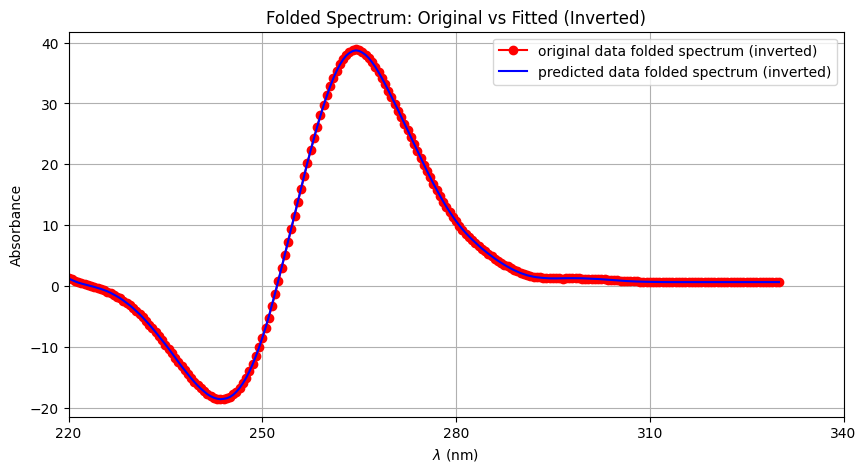

In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np
from matplotlib import pyplot as plt

spttr_F= df.iloc [:,0 ].values  # escludi la prima colonna (lunghezze d'onda)

reg = LinearRegression()

# Fit il modello direttamente senza ordinamento
reg.fit(U_prime, spttr_F)

# Coefficienti
C11, C21, C31 = reg.coef_
print(f"Coefficenti della regressione: C11={C11}, C21={C21}, C31={C31}")

# Predizione dei dati
predicted_F = reg.predict(U_prime)

# Invertiamo solo i dati di `spttr_F` e `predicted`, ma lasciamo `l_array` invariato
spttr_F_reversed = spttr_F[::-1]
predicted_reversed_F = predicted_F[::-1]

# Grafico
plt.figure(figsize=(10, 5))

# Grafico dei dati originali
plt.plot(l_array, spttr_F_reversed, label='original data folded spectrum (inverted)', marker='o', color='red')

# Grafico dei dati predetti
plt.plot(l_array, predicted_reversed_F, label='predicted data folded spectrum (inverted)', linestyle='-', color='blue')

# Titolo e etichette
plt.title('Folded Spectrum: Original vs Fitted (Inverted)')
plt.xlabel(r'$\lambda$ (nm)')
plt.xlim(min(l_array), max(l_array))
step_size = 30
ticks = np.arange(min(l_array), max(l_array) + step_size, step_size)
plt.xticks(ticks)

plt.ylabel('Absorbance')
plt.grid(True)
plt.legend()
plt.show()


Coefficenti:
C13: 0.012580350421504776, C23: 0.40423608266663147, C33: 0.17439882620973826


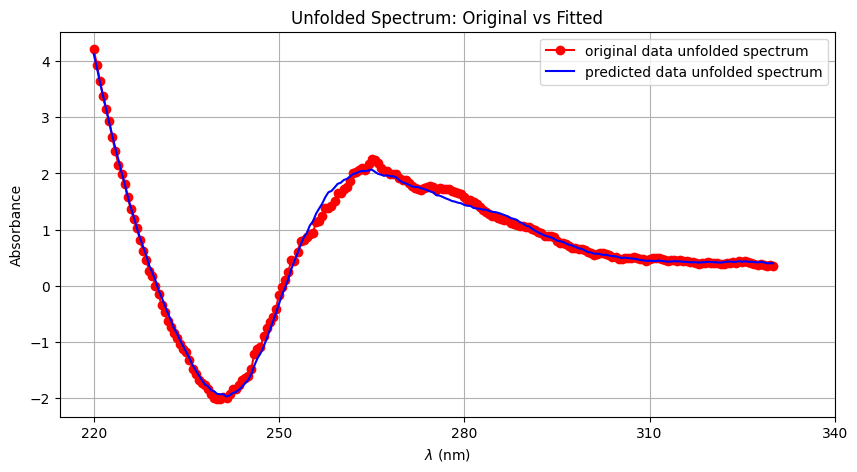

In [4]:
spttr_U = df.iloc[:, -1].values # ultima colonna (spettro unfolded)
reg.fit(U_prime, spttr_U)  # addestra il modello
C13,C23,C33 = reg.coef_  # coefficenti
predicted_U = reg.predict(U_prime)  # predizione
print("\nCoefficenti:")
print(f"C13: {C13}, C23: {C23}, C33: {C33}")

spttr_U_reversed = spttr_U[::-1]
predicted_reversed_U = predicted_U[::-1]

plt.figure(figsize=(10, 5))
plt.plot(l_array, spttr_U_reversed, label= 'original data unfolded spectrum', marker='o', color='red')
plt.plot(l_array, predicted_reversed_U, label= 'predicted data unfolded spectrum', linestyle='-', color='blue')
plt.title('Unfolded Spectrum: Original vs Fitted')
plt.xlabel(r'$\lambda$ (nm)')
step_size = 30
ticks = np.arange(min(l_array), max(l_array) + step_size, step_size)
plt.xticks(ticks)
plt.ylabel('Absorbance')
plt.grid(True)
plt.legend()
plt.show()

Ora abbiamo i primi 6 coefficienti.
Ci resta solamente da fare il fit globale grazie alle funzioni di Van't Hoff.

In [5]:
# Creazione array per le temperature
t_csv = pd.read_csv('matrice_con_t.dat', sep=',', header=None)
t_array = t_csv.iloc[0, 1:].astype(float).values # prima riga, da 2 in poi
T_kelvin = t_array + 273.15

R = 1.987  # cal/(mol·K)

print("\nTemperatura (K):")
print(T_kelvin[:5])  # prime 5 righe


Temperatura (K):
[293.15 295.15 297.15 299.15 301.15]


Qui è stato fatto un global-fit per il modello F<->I<->U.
In cui è ovviamante presente uno stadio intermedio tra la conformazione Folded and Unfolded. 

**MODELLO SEQUENZIALE**

In [6]:
def calc_M_2p(T, Tm1, Tm2, dH1, dH2):
    # calcolo M_i(T) per i tre stati
    A = np.exp(-dH1 / R * (1/Tm1 - 1/T))
    B = np.exp(-dH2 / R * (1/Tm2 - 1/T))
    denom = 1 + (A*B) + A
    M1 = 1 / denom
    M2 = A / denom
    M3 = (A*B) / denom
    return np.stack([M1, M2, M3], axis=0)  # shape (3, len(T))


from scipy.optimize import least_squares

def residui_p(params, T, V_prime, C_fix): # una funzione che restituisce SOLO la differenza tra i dati e il modello ma serve per far andare LeastSquares
    
    # costruisce C
    # calcola M_i(T) per i tre stati -> M
    # calcola f_i(T) = sum_j C_ij * M_j(T) -> f_pred
    # calcola residui = V_prime - f_pred -> residui

    # unpack parametri liberi
    Tm1, Tm2, dH1, dH2 = params[:4]
    C12, C22, C32 = params[4:]

    # ricostruisci tutti i Cij
    C = np.array([
        [C_fix['C11'], C12,  C_fix['C13']],
        [C_fix['C21'],          C22,  C_fix['C23']],
        [C_fix['C31'], C32,  C_fix['C33']]
    ])  # shape (3, 3)

    # calcolo le M_i(T)
    M = calc_M_2p(T, Tm1, Tm2, dH1, dH2)  # shape (3, len(T))

    # calcolo f_i(T) = sum_j C_ij * M_j(T)
    f_pred = C @ M  # shape (3, len(T))

    # flatten dei residui
    return (V_prime - f_pred).flatten()


# dizionario dei C fissi (già calcolati)
C_fix = {
    'C11': C11,
    'C21': C21,
    'C31': C31,
    'C13': C13,
    'C23': C23,
    'C33': C33
}

# valori iniziali plausibili (Tm in K, ΔH in cal/mol, C arbitrari)
p0 = [330, 354, -21000, -35000, 0.3, 0.3, 0.3] #valori per i parametri termodinamici presi circa da letteratura

residui_init = residui_p(p0, T_kelvin, V_prime, C_fix)
print("Valori iniziali dei residui:", residui_init[:10])
print("Contengono NaN?", np.any(np.isnan(residui_init)))
print("Contengono inf?", np.any(np.isinf(residui_init)))


# prova params fino a che sono minimi (1000) residui_p
# poi salva i params ottimizzati in res.x

res_p = least_squares( # chiama i residui con diversi params (prove)e trova i valori ottimali, al termine trovi tutto su res.x
    residui_p,
    p0,
    args=(T_kelvin, V_prime, C_fix),
    method='trf' # 'trf' è il metodo di Levenberg-Marquardt
)

# Stampa formattata dei parametri ottimizzati
param_labels = ['Tm1', 'Tm2', 'ΔH1', 'ΔH2', 'C12', 'C22', 'C32']
param_units = ['K', 'K', 'cal/mol', 'cal/mol', '', '', '']

print("\nParametri ottimizzati:")
for label, unit, value in zip(param_labels, param_units, res_p.x):
    print(f"{label:>4} = {value:10.2f} {unit}")


Valori iniziali dei residui: [-0.00201135 -0.00300526 -0.00362575 -0.00498582 -0.00589397 -0.00610029
 -0.00824739 -0.00959779 -0.01230181 -0.0144325 ]
Contengono NaN? False
Contengono inf? False

Parametri ottimizzati:
 Tm1 =     324.21 K
 Tm2 =     359.18 K
 ΔH1 =  -13052.21 cal/mol
 ΔH2 =  -58145.80 cal/mol
 C12 =       0.17 
 C22 =       0.01 
 C32 =      -0.38 


Il grafico connesso al fit con il chi quadro ridotto:

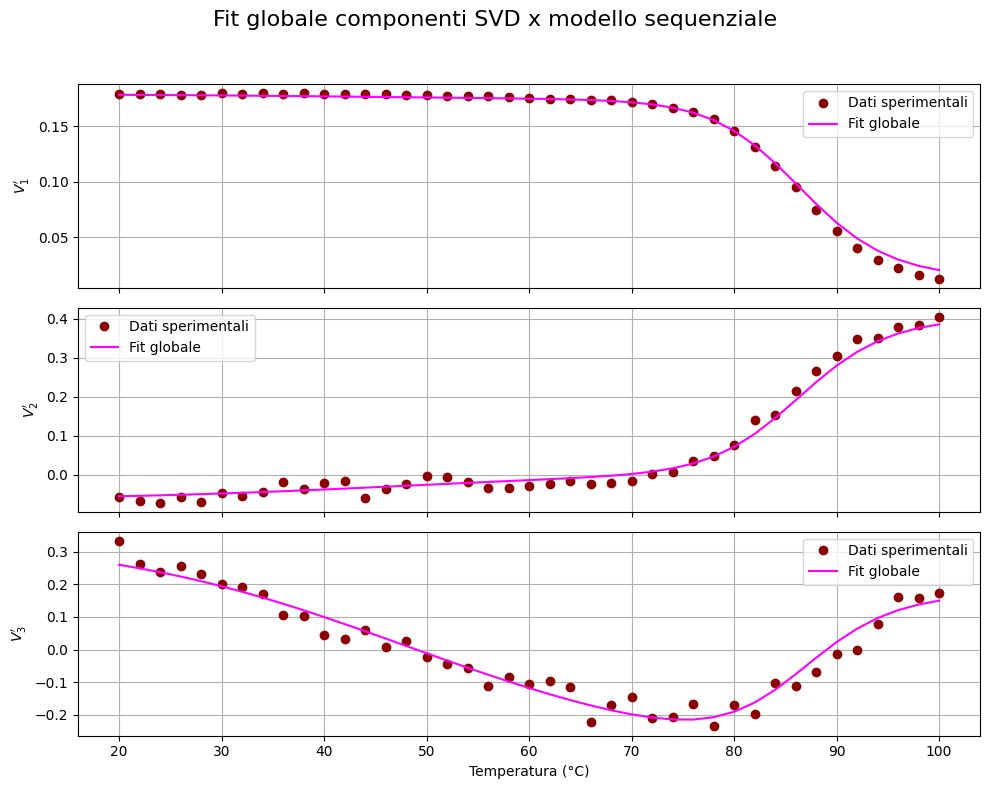


Chi quadro ridotto: 0.00047


In [7]:
Tm1, Tm2, dH1, dH2 = res_p.x[:4]
C12, C22, C32 = res_p.x[4:]

# ricostruzione della matrice C
C_opt = np.array([
    [C_fix['C11'], C12,  C_fix['C13']],
    [C_fix['C21'],          C22,  C_fix['C23']],
    [C_fix['C31'], C32,  C_fix['C33']]
])

# calcolo delle M con le T usate nel fit
M_opt_p_p = calc_M_2p(T_kelvin, Tm1, Tm2, dH1, dH2) # shape (3, len(T)) M ottimizzata
f_pred_p = C_opt @ M_opt_p_p  # shape (3, len(T))

# Calcolo chi quadro ridotto
residuals_p = V_prime - f_pred_p # residui
chi2_p = np.sum(residuals_p**2) # somma dei residui al quadrato (err tot)
dof = V_prime.size - len(res_p.x)  # gradi di libertà = numero di dati - numero di parametri
chi2_red_p = chi2_p / dof # chi quadro ridotto

# Plot
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = [r"$V_1'$", r"$V_2'$", r"$V_3'$"]

for i in range(3):
    axs[i].plot(t_array, V_prime[i], 'o', label='Dati sperimentali', color='darkred')
    axs[i].plot(t_array, f_pred_p[i], '-', label='Fit globale', color='magenta')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend()

axs[2].set_xlabel("Temperatura (°C)")
plt.suptitle(r"Fit globale componenti SVD x modello sequenziale", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(f"\nChi quadro ridotto: {chi2_red_p:.5f}")

**N.B.:** $\chi^2$ ridotto così piccolo normalmente indicherebbe un overfitting per assenza di rumore ma nel nostro caso stiamo filtrando il rumore con la tecnica SVD e quindi vogliamo che il  $\chi^2$ ridotto sia così piccolo.

Di seguito, invece, si considera di fittare per il modello F1<->U<->F2.

**MODELLO PARALLELO**

In [8]:
def calc_M_2s(T, Tm1, Tm2, dH1, dH2):
    # calcolo M_i(T) per i tre stati
    A = np.exp(-dH1 / R * (1/Tm1 - 1/T))
    B = np.exp(-dH2 / R * (1/Tm2 - 1/T))
    denom = 1 + A + B
    M1 = 1 / denom
    M2 = A / denom
    M3 = B / denom
    return np.stack([M1, M2, M3], axis=0)  # shape (3, len(T))


def residui_s(params, T, V_prime, C_fix):
    # unpack parametri liberi
    Tm1, Tm2, dH1, dH2 = params[:4]
    C12, C22, C32 = params[4:]

    # ricostruisci tutti i Cij
    C = np.array([
        [C_fix['C11'], C12,  C_fix['C13']],
        [C_fix['C21'],          C22,  C_fix['C23']],
        [C_fix['C31'], C32,  C_fix['C33']]
    ])  # shape (3, 3)

    # calcolo le M_i(T)
    M = calc_M_2s(T, Tm1, Tm2, dH1, dH2)  # shape (3, len(T))

    # calcolo f_i(T) = sum_j C_ij * M_j(T)
    f_pred = C @ M  # shape (3, len(T))

    # flatten dei residui
    return (V_prime - f_pred).flatten()


residui_init = residui_s(p0, T_kelvin, V_prime, C_fix)
print("Valori iniziali dei residui:", residui_init[:10])
print("Contengono NaN?", np.any(np.isnan(residui_init)))
print("Contengono inf?", np.any(np.isinf(residui_init)))


res_s = least_squares(
    residui_s,
    p0,
    args=(T_kelvin, V_prime, C_fix),
    method='trf'
)

# Stampa formattata dei parametri ottimizzati
param_labels = ['Tm1', 'Tm2', 'ΔH1', 'ΔH2', 'C12', 'C22', 'C32']
param_units = ['K', 'K', 'cal/mol', 'cal/mol', '', '', '']

print("\nParametri ottimizzati:")
for label, unit, value in zip(param_labels, param_units, res_s.x):
    print(f"{label:>4} = {value:10.2f} {unit}")

Valori iniziali dei residui: [-0.00200603 -0.00299732 -0.00361398 -0.0049685  -0.00586871 -0.00606374
 -0.00819503 -0.00952355 -0.01219781 -0.01428884]
Contengono NaN? False
Contengono inf? False

Parametri ottimizzati:
 Tm1 =     324.21 K
 Tm2 =     352.22 K
 ΔH1 =  -13052.24 cal/mol
 ΔH2 =  -71198.05 cal/mol
 C12 =       0.17 
 C22 =       0.01 
 C32 =      -0.38 


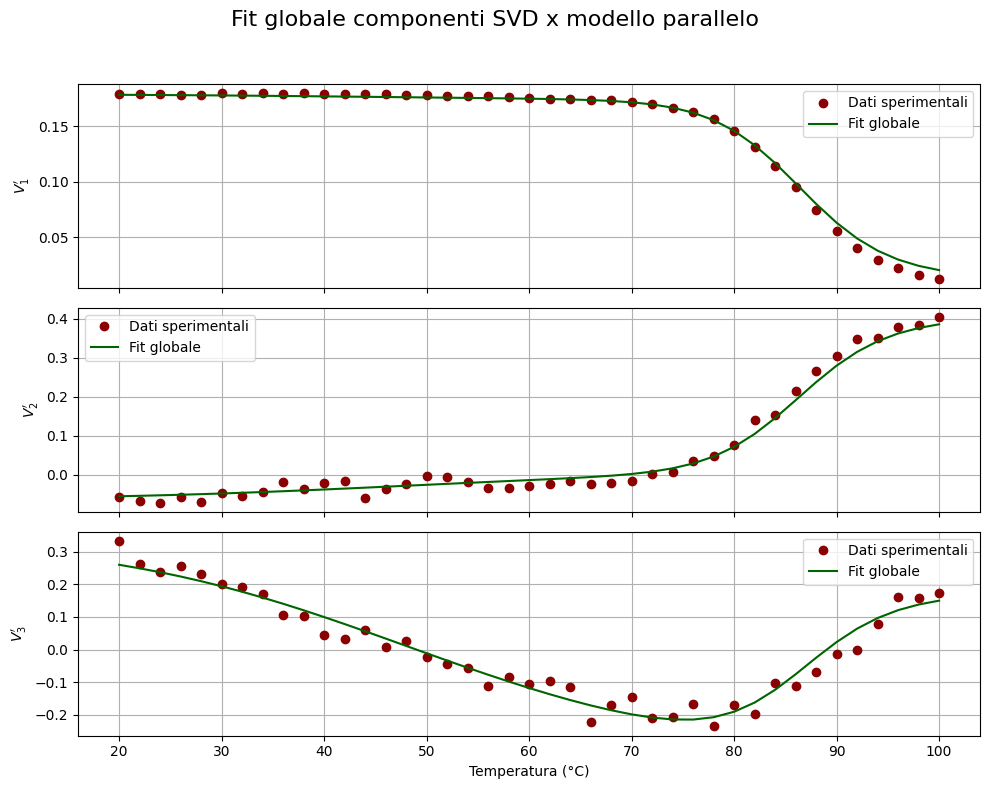


Chi quadro ridotto: 0.00047


In [9]:
Tm1, Tm2, dH1, dH2 = res_s.x[:4]
C12, C22, C32 = res_s.x[4:]

# ricostruzione della matrice C
C_opt = np.array([
    [C_fix['C11'], C12,  C_fix['C13']],
    [C_fix['C21'],          C22,  C_fix['C23']],
    [C_fix['C31'], C32,  C_fix['C33']]
])

# calcolo delle M con le T usate nel fit
M_opt_s = calc_M_2s(T_kelvin, Tm1, Tm2, dH1, dH2)
f_pred_s = C_opt @ M_opt_s  # shape (3, len(T))

# Calcolo chi quadro ridotto
residuals_s = V_prime - f_pred_s
chi2_s = np.sum(residuals_s**2) # somma dei residui al quadrato
dof = V_prime.size - len(res_s.x)  # gradi di libertà
chi2_red_s = chi2_s / dof # chi quadro ridotto

# Plot
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = [r"$V_1'$", r"$V_2'$", r"$V_3'$"]

for i in range(3):
    axs[i].plot(t_array, V_prime[i], 'o', label='Dati sperimentali', color='darkred')
    axs[i].plot(t_array, f_pred_s[i], '-', label='Fit globale', color='darkgreen')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend()

axs[2].set_xlabel("Temperatura (°C)")
plt.suptitle(r"Fit globale componenti SVD x modello parallelo", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(f"\nChi quadro ridotto: {chi2_red_s:.5f}")

Per ultima cosa confrontiamo visivamente i due fit per capire quale modello si adatta in maniera migliore al caso in esame

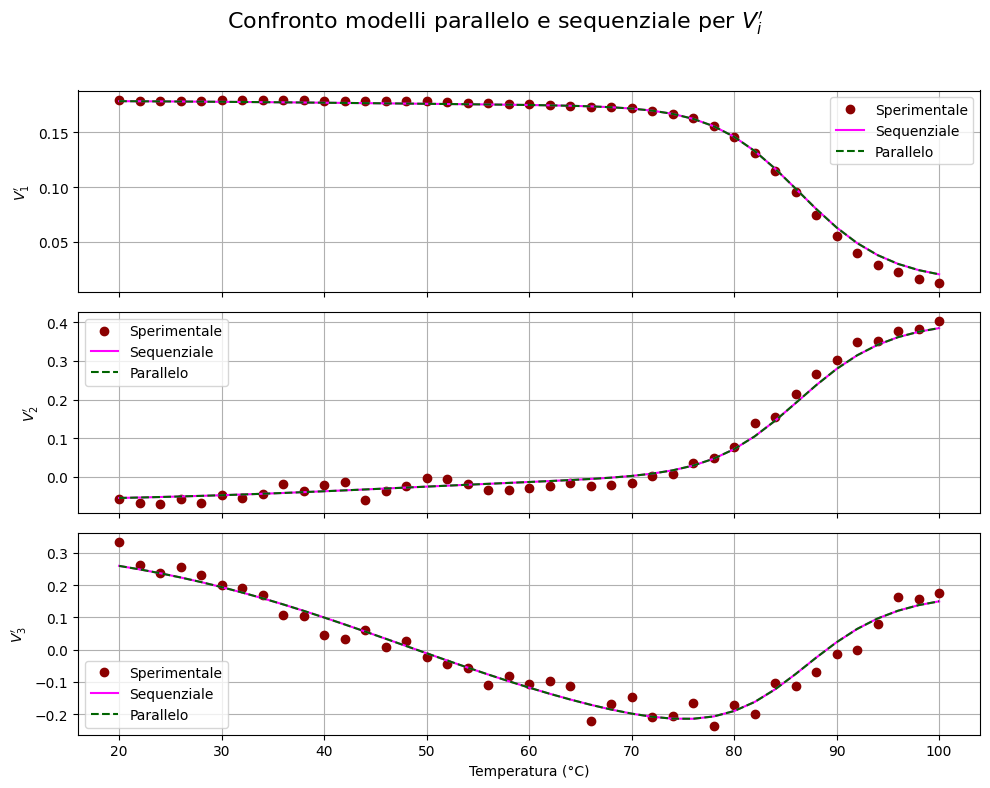

In [10]:
# Grafico comparativo dei due modelli
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = [r"$V_1'$", r"$V_2'$", r"$V_3'$"]

for i in range(3):
    axs[i].plot(t_array, V_prime[i], 'o', label='Sperimentale', color='darkred')
    axs[i].plot(t_array, f_pred_p[i], '-', label='Sequenziale', color='magenta')
    axs[i].plot(t_array, f_pred_s[i], '--', label='Parallelo', color='darkgreen')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend(loc='best')

axs[2].set_xlabel("Temperatura (°C)")
plt.suptitle(
    rf"Confronto modelli parallelo e sequenziale per $V_i'$", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Purtroppo sembrano adattarsi perfettamente ai dati entrambi i modelli.
Serve un metodo al fine di discriminarli, si usa quindi un approccio più fisico: si plottano le popolazioni dei 3 stati: 
- Nativo;
- Intermedio;
- Unfolded.


E, commentandole, si sceglie il criterio con il quale applicare la discriminazione:

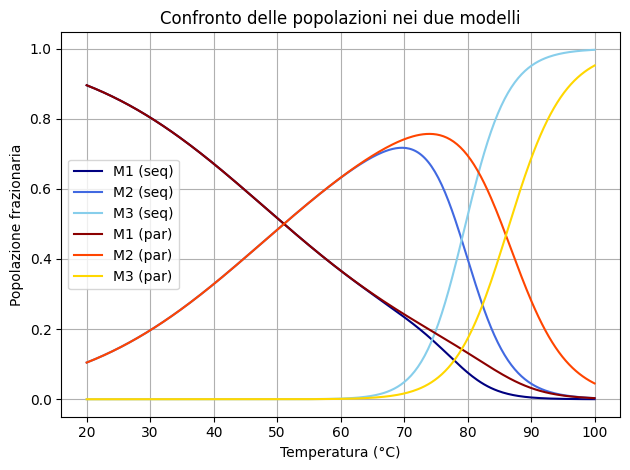

In [11]:
T_plot = np.linspace(min(T_kelvin), max(T_kelvin), 300)

# Modello SEQUENZIALE - toni di blu
M_seq = calc_M_2p(T_plot, Tm1, Tm2, dH1, dH2)
plt.plot(T_plot - 273.15, M_seq[0], label="M1 (seq)", color='navy')
plt.plot(T_plot - 273.15, M_seq[1], label="M2 (seq)", color='royalblue')
plt.plot(T_plot - 273.15, M_seq[2], label="M3 (seq)", color='skyblue')

# Modello PARALLELO - toni caldi
M_par = calc_M_2s(T_plot, Tm1, Tm2, dH1, dH2)
plt.plot(T_plot - 273.15, M_par[0], label="M1 (par)", color='darkred')
plt.plot(T_plot - 273.15, M_par[1], label="M2 (par)", color='orangered')
plt.plot(T_plot - 273.15, M_par[2], label="M3 (par)", color='gold')

# Decorazioni grafiche
plt.xlabel("Temperatura (°C)")
plt.ylabel("Popolazione frazionaria")
plt.title("Confronto delle popolazioni nei due modelli")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Notando le curve, anche se il campione c-MYC.


The unfolding proﬁles of c-MYC promoter oligonucleotide demonstrate a clearsingle G4-coil transition at 295 nm with the melting temperature (Tm) values of 64±0.3◦Cat 0.5 mM KCl and 71.7±0.3◦C at 5.0 mM KCl (Figure 2) [Effects of G-Quadruplex-Binding Plant Secondary Metaboliteson c-MYC ExpressionRoman G. Zenkov 1, Kirill I. Kirsanov 1,2 , Anna M. Ogloblina 1, Olga A. Vlasova 1, Denis S. Naberezhnov 1,Natalia Y. Karpechenko 1,3, Timur I. Fetisov 1, Ekaterina A. Lesovaya 1,4 , Gennady A. Belitsky 1,Nina G. Dolinnaya 5and Marianna G. Yakubovskaya] 


In lower KCl concentration of 20 mM,
the CD melting curves show that Pu27 G4 and Myc2345 G4
°
have a similar
Tm
of 70 °C, which is about 15 degrees higher
than the
Tm
obtained for Myc1245 G4 and Pu27-G17A G4 (see
SI, “
Circular dichroism spectroscopy”, Figure S1).
[Stability and Kinetics of c-MYC Promoter G‑Quadruplexes Studied by
Single-Molecule Manipulation
Huijuan You,† Jingyuan Wu,‡ Fangwei Shao,‡ and Jie Yan*,†,∥,]

Un'analisi qualitativa delle curve sperimentali di dicroismo circolare, registrate nell’intervallo di temperatura 20–100 °C, suggerisce che al termine del riscaldamento la struttura del campione risulti completamente denaturata. Tale osservazione appare più coerente con l’ipotesi di un meccanismo di unfolding sequenziale, nel quale la popolazione dell’ultimo stato cresce fino a raggiungere quasi il 100% alle alte temperature. In attesa di un supporto quantitativo derivante dalla letteratura, tale evidenza fornisce una prima indicazione a favore del modello sequenziale.

La scelta tra i due modelli di unfolding si è rivelata non immediata. Per sostenere tale scelta con dati quantitativi, è stato individuato un articolo di riferimento [Thermodynamic Stability and Folding Kinetics of the Major G-Quadruplex and Its Loop Isomers Formed in the Nuclease Hypersensitive Element in the Human c-Myc Promoter, Hatzakis et al.] che riporta i valori di temperatura di melting (Tm) della sequenza 14/23 del promotore c-MYC in funzione della concentrazione di ioni potassio.

Sebbene i dati sperimentali fossero limitati, si è scelto di costruire un modello semi-empirico per stimare la Tm a 70 mM di KCl, valore rilevante per l’interpretazione dei dati sperimentali. Il comportamento asintotico osservato alle alte concentrazioni di K⁺ ha motivato l’adozione di una funzione di fitting basata su una radice dodicesima della concentrazione.

Per quantificare l’incertezza della stima ottenuta, è stato impiegato il metodo di bootstrap, che ha permesso di generare un intervallo di confidenza a partire da numerose rifit su campioni resampling dei dati disponibili. Questo approccio ha fornito non solo una stima puntuale della Tm, ma anche una misura affidabile della sua variabilità statistica.

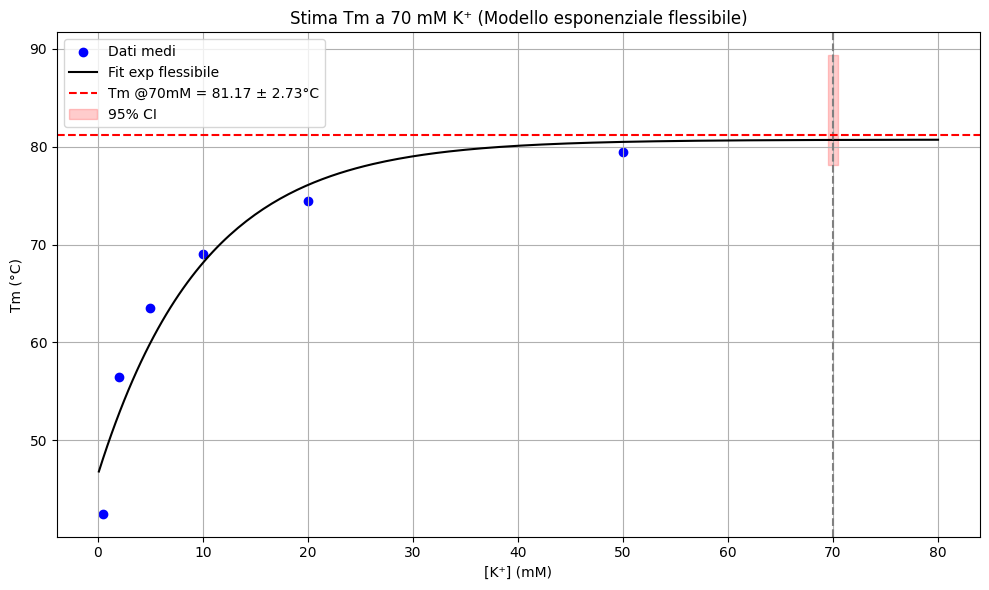

Stima Tm a 70 mM KCl: 81.17 °C
Intervallo di confidenza 95%: 78.15 – 89.35 °C

Temperatura di melting media stimata (sequenziale): 86.03 °C
Temperatura di melting media stimata (parallelo): 79.07 °C


In [12]:
from sklearn.utils import resample
from scipy.optimize import curve_fit

# Dati sperimentali
K_conc = np.array([0.5, 2, 5, 10, 20, 50]).reshape(-1, 1)  # mM
Tm1 = np.array([43, 57, 64, 69, 75, 80])
Tm2 = np.array([42, 56, 63, 69, 74, 79])
Tm_avg = (Tm1 + Tm2) / 2

# Nuovo modello: a - b * exp(-(K/d)^c)
def flexible_neg_exp_model(K, a, b, d, c):
    return a - b * np.exp(-(K / d) ** c)

# Fit con valori iniziali e bounds
p0 = [86, 45, 50, 2]
bounds = ([78, 1, 10, 1], [95, 80, 200, 5])
popt, _ = curve_fit(flexible_neg_exp_model, K_conc.ravel(), Tm_avg, p0=p0, bounds=bounds)
a_fit, b_fit, d_fit, c_fit = popt

# Stima a 70 mM
Tm_pred = flexible_neg_exp_model(70, a_fit, b_fit, d_fit, c_fit)

# Bootstrap per intervallo di confidenza
predictions = []
for _ in range(1000):
    X_res, y_res = resample(K_conc.ravel(), Tm_avg)
    try:
        popt_bs, _ = curve_fit(flexible_neg_exp_model, X_res, y_res, p0=p0, bounds=bounds, maxfev=5000)
        pred = flexible_neg_exp_model(70, *popt_bs)
        predictions.append(pred)
    except RuntimeError:
        continue

mean_pred = np.mean(predictions)
std_pred = np.std(predictions)
conf_int = (
    np.percentile(predictions, 2.5),
    np.percentile(predictions, 97.5)
)

# Plot
K_plot = np.linspace(0.1, 80, 200)
Tm_plot = flexible_neg_exp_model(K_plot, a_fit, b_fit, d_fit, c_fit)

plt.figure(figsize=(10, 6))
plt.scatter(K_conc, Tm_avg, label='Dati medi', color='blue')
plt.plot(K_plot, Tm_plot, label='Fit exp flessibile', color='black')
plt.axvline(70, linestyle='--', color='gray')
plt.axhline(mean_pred, linestyle='--', color='red', label=f'Tm @70mM = {mean_pred:.2f} ± {std_pred:.2f}°C')
plt.fill_between([69.5, 70.5], conf_int[0], conf_int[1], color='red', alpha=0.2, label='95% CI')
plt.xlabel('[K⁺] (mM)')
plt.ylabel('Tm (°C)')
plt.title('Stima Tm a 70 mM K⁺ (Modello esponenziale flessibile)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Stima Tm a 70 mM KCl: {mean_pred:.2f} °C")
print(f"Intervallo di confidenza 95%: {conf_int[0]:.2f} – {conf_int[1]:.2f} °C")

# Aggiunta righe richieste (confronto con modelli termodinamici)
tm_conf_s = res_p.x[1] - 273.15  # in °C
print(f"\nTemperatura di melting media stimata (sequenziale): {tm_conf_s:.2f} °C")

tm_conf_p = res_s.x[1] - 273.15  # in °C
print(f"Temperatura di melting media stimata (parallelo): {tm_conf_p:.2f} °C")


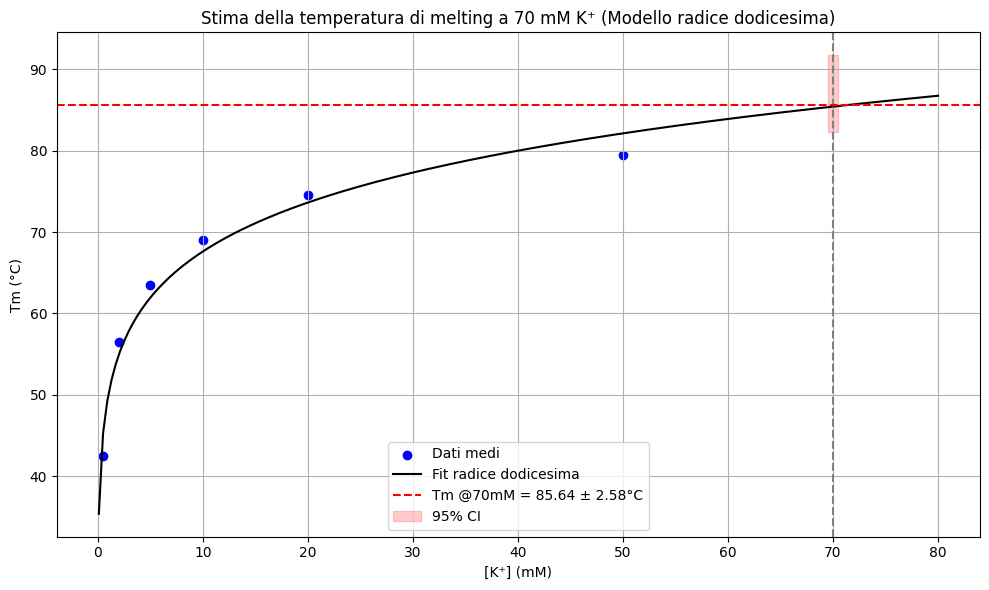

Stima Tm a 70 mM KCl: 85.64 °C
Intervallo di confidenza 95%: 82.28 – 91.73 °C


In [13]:
# Dati sperimentali: concentrazione [K⁺] e Tm mediata tra due metodi
K_conc = np.array([0.5, 2, 5, 10, 20, 50]).reshape(-1, 1)  # mM
Tm1 = np.array([43, 57, 64, 69, 75, 80])
Tm2 = np.array([42, 56, 63, 69, 74, 79])
Tm_avg = (Tm1 + Tm2) / 2

# Definisco il modello da fittare: Tm = a * [K⁺]^(1/12) + b
def twelfth_root_model(x, a, b):
    return a * np.power(x, 1/12) + b

# Fit del modello ai dati (ottimizzazione non lineare)
popt_12rt, pcov_12rt = curve_fit(twelfth_root_model, K_conc.ravel(), Tm_avg)
a_fit_12rt, b_fit_12rt = popt_12rt

# Calcolo Tm stimata a 70 mM
Tm_pred_12rt = twelfth_root_model(70, a_fit_12rt, b_fit_12rt)

# Eseguo bootstrap per stimare la variabilità della stima
predictions_12rt = []
for _ in range(1000):
    X_resampled, y_resampled = resample(K_conc.ravel(), Tm_avg)
    try:
        popt_bs, _ = curve_fit(twelfth_root_model, X_resampled, y_resampled, maxfev=5000)
        pred = twelfth_root_model(70, *popt_bs)
        predictions_12rt.append(pred)
    except RuntimeError:
        continue

# Calcolo media, deviazione standard, intervallo di confidenza (percentili)
mean_pred = np.mean(predictions_12rt)
std_pred = np.std(predictions_12rt)
conf_int = (
    np.percentile(predictions_12rt, 2.5),
    np.percentile(predictions_12rt, 97.5)
)

# Preparo il grafico del fit e dell'incertezza
K_plot = np.linspace(0.1, 80, 200)
Tm_plot = twelfth_root_model(K_plot, a_fit_12rt, b_fit_12rt)

plt.figure(figsize=(10, 6))
plt.scatter(K_conc, Tm_avg, label='Dati medi', color='blue')
plt.plot(K_plot, Tm_plot, label='Fit radice dodicesima', color='black')
plt.axvline(70, linestyle='--', color='gray')
plt.axhline(mean_pred, linestyle='--', color='red', label=f'Tm @70mM = {mean_pred:.2f} ± {std_pred:.2f}°C')
plt.fill_between([69.5, 70.5], conf_int[0], conf_int[1], color='red', alpha=0.2, label='95% CI')
plt.xlabel('[K⁺] (mM)')
plt.ylabel('Tm (°C)')
plt.title('Stima della temperatura di melting a 70 mM K⁺ (Modello radice dodicesima)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Stima Tm a 70 mM KCl: {mean_pred:.2f} °C")
print(f"Intervallo di confidenza 95%: {conf_int[0]:.2f} – {conf_int[1]:.2f} °C")

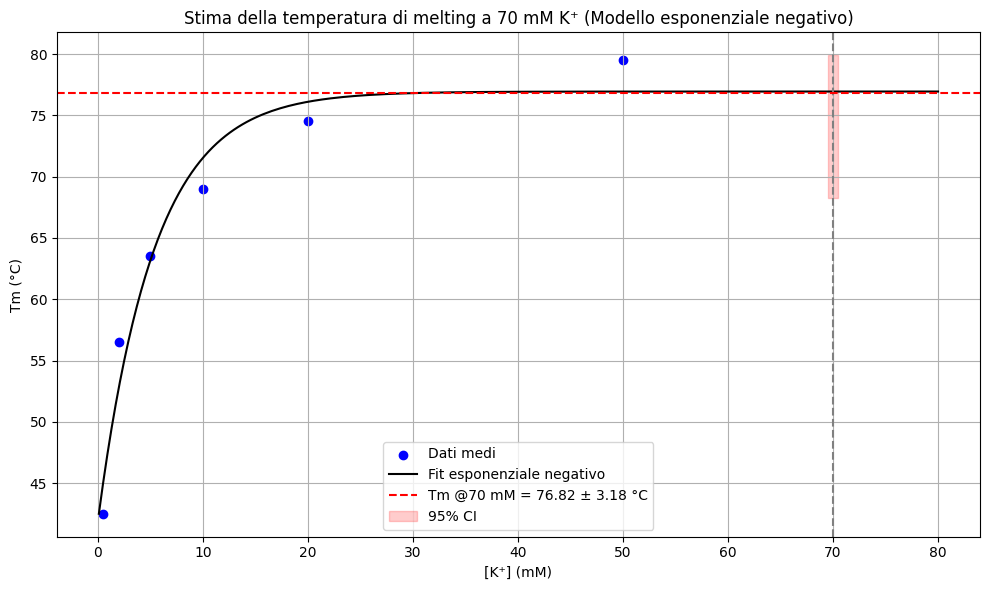

Stima Tm a 70 mM KCl: 76.82 °C
Intervallo di confidenza 95%: 68.27 – 79.90 °C


In [14]:
from sklearn.utils import resample
from scipy.optimize import curve_fit

# Dati sperimentali: concentrazione [K⁺] e Tm mediata
K_conc = np.array([0.5, 2, 5, 10, 20, 50]).reshape(-1, 1)  # in mM
Tm1 = np.array([43, 57, 64, 69, 75, 80])
Tm2 = np.array([42, 56, 63, 69, 74, 79])
Tm_avg = (Tm1 + Tm2) / 2

# Modello esponenziale negativo: Tm = a - b * exp(-c * x), con protezione overflow
def neg_exp_model(x, a, b, c):
    z = -c * x
    z = np.clip(z, -700, 700)  # Evita overflow numerico
    return a - b * np.exp(z)

# Fit con vincoli ragionevoli
popt_exp, pcov_exp = curve_fit(
    neg_exp_model,
    K_conc.ravel(),
    Tm_avg,
    bounds=([50, 0, 0], [100, 100, 1]),
    maxfev=5000
)
a_fit, b_fit, c_fit = popt_exp

# Stima a 70 mM
Tm_pred = neg_exp_model(70, a_fit, b_fit, c_fit)

# Bootstrap per incertezza
predictions = []
for _ in range(1000):
    X_resampled, y_resampled = resample(K_conc.ravel(), Tm_avg)
    try:
        popt_bs, _ = curve_fit(
            neg_exp_model,
            X_resampled,
            y_resampled,
            bounds=([50, 0, 0], [100, 100, 1]),
            maxfev=5000
        )
        pred = neg_exp_model(70, *popt_bs)
        predictions.append(pred)
    except RuntimeError:
        continue

# Statistiche bootstrap
mean_pred = np.mean(predictions)
std_pred = np.std(predictions)
conf_int = np.percentile(predictions, [2.5, 97.5])

# Plot
K_plot = np.linspace(0.1, 80, 200)
Tm_plot = neg_exp_model(K_plot, a_fit, b_fit, c_fit)

plt.figure(figsize=(10, 6))
plt.scatter(K_conc, Tm_avg, label='Dati medi', color='blue')
plt.plot(K_plot, Tm_plot, label='Fit esponenziale negativo', color='black')
plt.axvline(70, linestyle='--', color='gray')
plt.axhline(mean_pred, linestyle='--', color='red', label=f'Tm @70 mM = {mean_pred:.2f} ± {std_pred:.2f} °C')
plt.fill_between([69.5, 70.5], conf_int[0], conf_int[1], color='red', alpha=0.2, label='95% CI')
plt.xlabel('[K⁺] (mM)')
plt.ylabel('Tm (°C)')
plt.title('Stima della temperatura di melting a 70 mM K⁺ (Modello esponenziale negativo)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Stima Tm a 70 mM KCl: {mean_pred:.2f} °C")
print(f"Intervallo di confidenza 95%: {conf_int[0]:.2f} – {conf_int[1]:.2f} °C")


Ora io ho fittato i due modelli e capito quale dei due è il caso che sto studiando: ora vado a rifittare per il modello scelto i $C_{i,j} $ che avevo in precedenza tenuti fissi.

Richiamo la funzione che avevo ottimizzato f_pred_p e la fitto lasciando i parametri precedentemente fissati come liberi e quelli liberi fissati.

Questo secondo fit è fortemente dipendente dalle forme degli spettri; in questo caso ho scelto di tenere fissi i parametri termodinamici che sembrano in linea con i valori in letterautra.
Verrà quindi fatto il secondo fit per i coefficienti dello stato folded and intermediate.

In [15]:
tot_params = [C11, C12, C13, C21, C22, C23, C31, C32, C33]  # tutti i parametri da ottimizzare 
Tm1, Tm2, dH1, dH2 = res_p.x[:4]


def residui_totali(tot_params, T, V_prime, modello_fn, Tm1, Tm2, dH1, dH2):  
    
    C11, C12, C13, C21,C22, C23, C31, C32, C33 = tot_params
    C = np.array([
        [C11, C12, C13],
        [C21, C22, C23],
        [C31, C32, C33]
    ])  # ricostruisce la matrice 3x3

    M = modello_fn(T, Tm1, Tm2, dH1, dH2)  # M.shape = (3, len(T))
    f_pred = C @ M
    return (V_prime - f_pred).flatten()


tot_p0 = [
    C_fix['C11'],        # C11
    res_p.x[4],          # C12 (dal primo fit)
    C_fix['C13'],        # C13
    C_fix['C21'],        # C21
    res_p.x[5],          # C22
    C_fix['C23'],        # C23
    C_fix['C31'],        # C31
    res_p.x[6],          # C32
    C_fix['C33']         # C33
]


tot_res = least_squares(
    residui_totali,
    tot_p0,
    args=(T_kelvin, V_prime, calc_M_2p, Tm1, Tm2, dH1, dH2),
    method='trf'
)

tot_c_labels = ['C11', 'C12', 'C13', 'C21', 'C22', 'C23', 'C31', 'C32', 'C33']
print("\nParametri C ottimizzati (con Tm e ΔH fissi):")
for label, value in zip(tot_c_labels, tot_res.x):
    print(f"{label} = {value:.4f}")




Parametri C ottimizzati (con Tm e ΔH fissi):
C11 = 0.1808
C12 = 0.1736
C13 = 0.0031
C21 = -0.0667
C22 = 0.0114
C23 = 0.4304
C31 = 0.3417
C32 = -0.3833
C33 = 0.1649


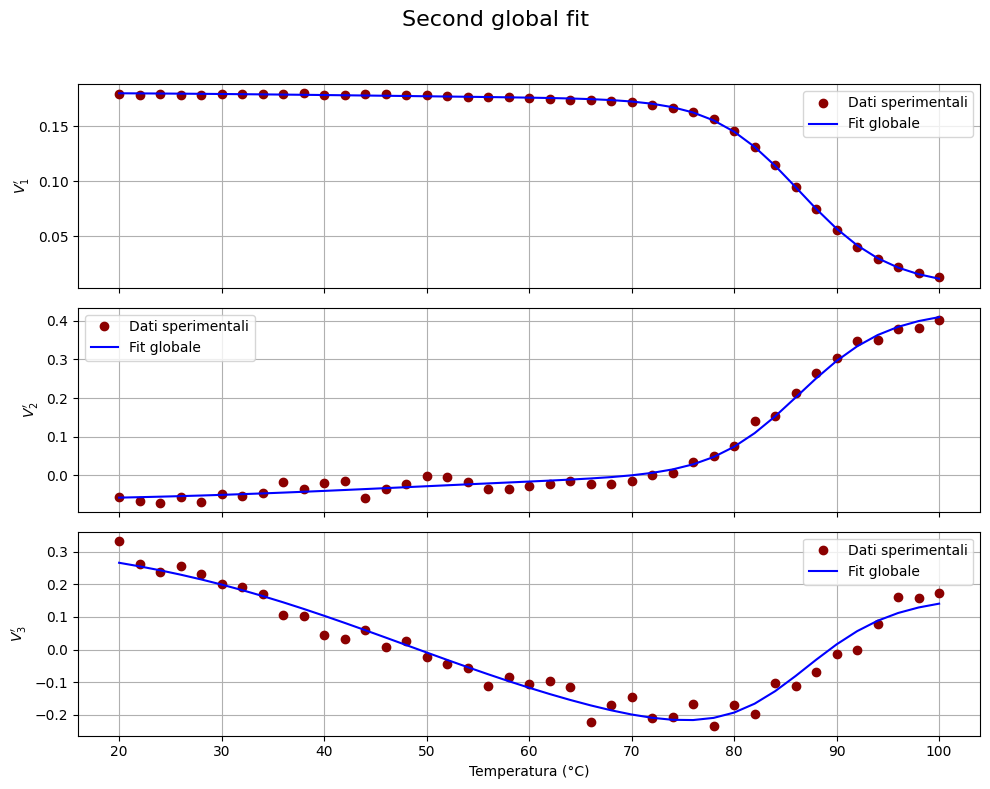


Chi quadro ridotto: 0.00044


In [16]:
# Ricostruzione della matrice C ottimizzata
C11, C12, C13, C21, C22, C23, C31, C32, C33 = tot_res.x
C_opt = np.array([
    [C11, C12, C13],
    [C21, C22, C23],
    [C31, C32, C33]
])

# Calcolo delle M con i T fissi FINALI
M_opt_secfit = calc_M_2p(T_kelvin, Tm1, Tm2, dH1, dH2)
f_pred_secfit = C_opt @ M_opt_secfit  # shape (3, len(T))

# Calcolo chi² ridotto
residuals = V_prime - f_pred_secfit
chi2 = np.sum(residuals**2)
dof = V_prime.size - len(tot_res.x)
chi2_red = chi2 / dof


# Plot
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = [r"$V_1'$", r"$V_2'$", r"$V_3'$"]

for i in range(3):
    axs[i].plot(T_kelvin - 273.15, V_prime[i], 'o', label='Dati sperimentali', color='darkred')
    axs[i].plot(T_kelvin - 273.15, f_pred_secfit[i], '-', label='Fit globale', color='blue')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend()

axs[2].set_xlabel("Temperatura (°C)")
plt.suptitle("Second global fit", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"\nChi quadro ridotto: {chi2_red:.5f}")


Per ultima cosa, salvo i parametri ottimizzati (tutti e 13), in un file csv che useremo nel prossimo programma al fine di ricostruire gli spettri.

In [17]:
# salva i parametri ottimizzati in un file CSV
parametri_ottimizzati = pd.DataFrame({
    'Parametri': ['Tm1', 'Tm2', 'dH1', 'dH2', 'C11', 'C12', 'C13', 'C21', 'C22', 'C23', 'C31', 'C32', 'C33'],   
    'Valori': [Tm1, Tm2, dH1, dH2, C11, C12, C13, C21, C22, C23, C31, C32, C33]
})

parametri_ottimizzati.head()

,Parametri,Valori
0,Tm1,324.213553
1,Tm2,359.183032
2,dH1,-13052.206883
3,dH2,-58145.799918
4,C11,0.180780


In [18]:


param_file = Path("parametri_ottimizzati.csv")
M_file = Path("M_matrix.csv")

if not param_file.exists():
    parametri_ottimizzati.to_csv(param_file, sep="\t", index=False, header=False)

if not M_file.exists():
    pd.DataFrame(M_opt_secfit).to_csv(M_file, sep="\t", index=False, header=False)


## Monte Carlo

In generale i risultati riportati in questa sezione (e allo stesso modo in altri paper scentifici (cita paper)) non hanno errori associati.
Questo perché la misura è unica, non può essere replicata dato che il campione in esame una volta studiato perde le proprie proprietà.
Questo problema venne portato alla luce (nel campo della bio-fisica in particolare) da Harry A. Saroff, questa parte finale di stima degli errori si basa sul suo metodo (cita saroff).


Per prima cosa è necessario capire di che ordine di grandezza sono gli errori strumentali dello strumento usato che, in questo caso, sono riportati nello sheet di Jasco 810 (cita). Risulta per un intervallo di circa 200 nm, con spectral bandwidth: verosimilmente 1 nm (compatibile con quella del datasheet). Reponse time effettivo abbastanza lungo per abbattere il rumore (90s) con la full scale impostata a $\pm 200$ mdeg ci fornisce una sensibilità di 0.01 mdeg.

Ora sempre il datasheet riporta una RMS noise @200 nm di 0.040 mdeg. Che è la varianza che andremo ad usare per calcolare il metodo Monte Carlo.


In questa cella si stima lo scarto atteso sui dati ridotti V', che saranno perturbati nel metodo Monte Carlo.  
Per stimare la deviazione standard $ \sigma_{\text{V'}} $ da iniettare nei dati ridotti V', si è considerata la propagazione del rumore sperimentale $ \sigma_{\text{CD}} $ attraverso la decomposizione SVD. Poiché le componenti principali selezionate nel fit rappresentano una proiezione dello spazio originale dei dati, anche il rumore viene in parte proiettato in questo sottospazio.
La deviazione standard è dunque scalata in base alla frazione di varianza spiegata dalle prime $ n $ component:

$$
\sigma_{V'} = \sigma_{\text{CD}} \cdot \sqrt{\sum_{k=1}^{n} R^2_k}
$$

dove $ R^2_k $ è la frazione di varianza spiegata dalla componente  k-esima, definita come:

$$
R^2_k = \frac{\lambda_k^2}{\sum_{j=1}^{m} \lambda_j^2}
$$

con $ \lambda_k $ il valore singolare della k-esima componente, $ m $ il numero totale di componenti, e $ n \leq m $ il numero di componenti effettivamente utilizzate per il fit (nel nostro caso, $ n = 3 $).

In [19]:
def calcola_sigma_MC_totale(sigma_CD, matrice_originale, n_componenti=4):
    """
    Calcola la deviazione standard sigma_MC da usare nel metodo Monte Carlo,
    stimando la frazione di varianza spiegata con una SVD completa (np.linalg.svd).

    Parameters:
    - sigma_CD: errore sperimentale in mdeg (strumentale)
    - matrice_originale: matrice dei dati spettrali grezzi (es. shape = [n_lambda, n_temperatura])
    - n_componenti: numero di componenti principali da considerare (default = 4)

    Returns:
    - sigma_MC: deviazione standard coerente per il Monte Carlo
    """
    # SVD completa per stimare la varianza spiegata cumulativa
    U, S_full, Vt = np.linalg.svd(matrice_originale, full_matrices=False)
    
    var_totale = np.sum(S_full**2)
    var_spiegata = np.sum(S_full[:n_componenti]**2)
    frazione_varianza = var_spiegata / var_totale

    sigma_MC = sigma_CD * np.sqrt(frazione_varianza)

    print(f"Varianza spiegata stimata con SVD completa (prime {n_componenti} componenti): {frazione_varianza:.5f}")
    print(f"σ_MC da usare per il Monte Carlo: {sigma_MC:.5f} (in mdeg compatibili con V')")


    return sigma_MC

# Esempio d'uso
sigma_MC = calcola_sigma_MC_totale(sigma_CD=0.040, matrice_originale=df.values, n_componenti=3)



Varianza spiegata stimata con SVD completa (prime 3 componenti): 0.99996
σ_MC da usare per il Monte Carlo: 0.04000 (in mdeg compatibili con V')


> Per stimare in modo realistico l'entità del rumore da iniettare nel metodo Monte Carlo,
> si utilizza una SVD completa sulla matrice originale: questo consente di valutare la
> frazione di varianza spiegata dalle prime componenti, anche se successivamente si
> utilizza una Truncated SVD per la riduzione. In questo modo si evita di sovrastimare
> l'incertezza legata all'errore strumentale.


La varianza spiegata (percentuale di informazione riportata) dalle prime 3 componenti risulta circa del 100%. Questo fa sì che la deviazione standard da usare nel metodo Monte Carlo sia circa 0.40: proprio la RMS noise. 

Questo check è stato comunque fondamentale in quanto non sempre si ricostruisce lo spettro usando un numero di componenti così alto, di conseguenza non era scontato che tutta la varianza fosse spiegata, e quindi il rumore che avremmo dovuto iniettare sarebbe stato inferiore.

Nel caso in esame, si sono usate tutte le componenti significative della SVD => nessuna informazione è andata persa (nemmeno il rumore).

In [20]:
residuals_s = V_prime - f_pred_p
sigma = np.std(residuals_s)
print(f"Stima del rumore residuo del modello, calcolando la deviazione standard tra le componenti ricostruite: {sigma:.4f}")


Stima del rumore residuo del modello, calcolando la deviazione standard tra le componenti ricostruite: 0.0210


Per stimare la deviazione standard da utilizzare nella simulazione Monte Carlo ($\sigma_{\text{MC}}$), sono stati considerati due approcci distinti.

Il primo approccio (coerente con il Metodo B del paper di riferimento) sfrutta l'errore strumentale noto dello spettropolarimetro, pari a $\sigma_{\text{CD}} = 0.040\,\text{mdeg}$, combinato con l'informazione sulla varianza spiegata dalle componenti principali ottenute tramite SVD (come spiegato sopra).

Il secondo approccio, alternativo, consiste nello stimare direttamente il rumore residuo del modello, calcolando la deviazione standard tra le componenti ricostruite $f_{\text{pred}}$ e quelle effettive $V'$:

$$
\sigma_{\text{residui}} = \text{std}(V' - f_{\text{pred}})
$$

Tuttavia, quest'ultima stima restituisce un valore $\sigma_{\text{residui}} \approx 0.021\,\text{mdeg}$, significativamente inferiore all'errore strumentale dichiarato. Inoltre, il $\chi^2$ ridotto del modello si è rivelato piccolo come già discusso: 

$$
\tilde{\chi}^2 \approx 0.00044
$$

, suggerendo una scarsa attendibilità per lo studio dell'errore (overfitting anche dell'errore).

Alla luce di ciò, si è scelto di adottare il primo metodo per garantire una stima dell'incertezza più conservativa, coerente con i limiti sperimentali e con il paper di inspirazione.


In questa cella si implementa il metodo Monte Carlo per stimare l'incertezza sui parametri del fit:

1) Si aggiunge rumore realistico ai dati ridotti $V'$ con deviazione standard $\sigma_{MC}$, coerente con l'errore strumentale e la varianza spiegata;

2) I parametri del primo fit vengono rifittati su $V'_{\text{sim}}$, ottenuto perturbando $V'$;

3) L'incertezza sui parametri viene stimata come la deviazione standard delle soluzioni ottenute, mantenendo fissi i valori nominali del primo fit.



In [21]:
# Lista per raccogliere i risultati delle simulazioni
parametri_MC1 = []
success_count = 0
n_iter = 500

for i in range(n_iter):
    # Aggiunta di rumore ai dati ridotti V'
    V_sim = V_prime + np.random.normal(0, sigma_MC, size=V_prime.shape)

    try:
        res_MC1 = least_squares(
            residui_p,
            res_p.x,
            args=(T_kelvin, V_sim, C_fix),
            method='trf',
        )

        if not res_MC1.success:
            continue

        # Estrazione parametri solo per calcolare incertezze
        Tm1_MC1 = res_MC1.x[0]
        Tm2_MC1 = Tm1_MC1 + abs(res_MC1.x[1])
        Tm3_MC1 = Tm2_MC1 + abs(res_MC1.x[2])
        rest = list(res_MC1.x[3:])
        parametri_MC1.append([Tm1_MC1, Tm2_MC1, Tm3_MC1] + rest)
        success_count += 1

    except Exception as e:
        print(f"Errore iterazione {i}: {e}")

print(f"Iterazioni riuscite: {success_count} su {n_iter}")

# Calcolo errore da Monte Carlo
if len(parametri_MC1) == 0:
    print("Nessuna iterazione Monte Carlo ha avuto successo.")
else:
    parametri_MC1 = np.array(parametri_MC1)
    std_params1 = np.std(parametri_MC1, axis=0)

    # Parametri veri dal fit iniziale (res_s)
    Tm1_fit1 = res_p.x[0]
    Tm2_fit1 = res_p.x[1]
    altri_parametri = list(res_p.x[2:])
    parametri_fit = [Tm1_fit1, Tm2_fit1] + altri_parametri

    labels1 = ['Tm1', 'Tm2', 'ΔH1', 'ΔH2',
               'C12', 'C22', 'C32'][:len(parametri_fit)]

    print("\nParametri finali ± errore stimato (Monte Carlo):")
    for label, val, err in zip(labels1, parametri_fit, std_params1):
        print(f"{label:>4} = {val:10.3f} \u00B1 {err:.3f}")


Iterazioni riuscite: 500 su 500

Parametri finali ± errore stimato (Monte Carlo):
 Tm1 =    324.214 ± 6.412
 Tm2 =    359.183 ± 5.589
 ΔH1 = -13052.207 ± 1928.447
 ΔH2 = -58145.800 ± 7025.807
 C12 =      0.173 ± 0.014
 C22 =      0.014 ± 0.019
 C32 =     -0.381 ± 0.135


In [22]:
from IPython.display import display
import ipywidgets as widgets

def plot_parametro(parametro):
    idx = labels1.index(parametro)
    valori = parametri_MC1[:, idx]
    valore_fit = parametri_fit[idx]  # valore "vero" dal fit

    plt.figure(figsize=(7, 4))
    plt.hist(valori, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(valore_fit, color='red', linestyle='--', linewidth=2, label='Valore fit')
    plt.title(f"Distribuzione Monte Carlo: {parametro}")
    plt.xlabel(parametro)
    plt.ylabel("Frequenza")
    plt.grid(True)
    plt.show()

menu = widgets.Dropdown(
    options=labels1,
    description='Parametro:',
    layout={'width': '300px'}
)

widgets.interact(plot_parametro, parametro=menu)

interactive(children=(Dropdown(description='Parametro:', layout=Layout(width='300px'), options=('Tm1', 'Tm2', …

<function __main__.plot_parametro(parametro)>

Per il secondo fit si fa la stessa cosa al fine ultimo di salvare gli errori per tutti i parametri.

In [23]:
# --- MONTE CARLO per il secondo fit (solo stima incertezze) ---
parametri_MC2 = []
success_count = 0
n_iter = 500

for i in range(n_iter):
    V_sim = V_prime + np.random.normal(0, sigma_MC, size=V_prime.shape)

    try:
        res_MC2 = least_squares(
            residui_totali,
            tot_res.x,  # uso i parametri ottimali del secondo fit
            args=(T_kelvin, V_sim, calc_M_2p, Tm1, Tm2, dH1, dH2),
            method='trf',
        )

        if not res_MC2.success:
            continue

        # Ricostruzione coerente dei parametri per stimare le incertezze
        C11, C12, C13 = res_MC2.x[:3]
        C21, C22, C23 = res_MC2.x[3:6]
        C31, C32, C33 = res_MC2.x[6:]

        parametri_MC2.append([C11, C12, C13, C21, C22, C23, C31, C32, C33])
        success_count += 1

    except Exception as e:
        print(f"Errore iterazione {i}: {e}")

print(f"Iterazioni riuscite: {success_count} su {n_iter}")

# --- Calcolo incertezze Monte Carlo, ma media dal secondo fit ---
if len(parametri_MC2) == 0:
    print("Nessuna iterazione Monte Carlo ha avuto successo.")
else:
    parametri_MC2 = np.array(parametri_MC2)
    std_params2 = np.std(parametri_MC2, axis=0)

    # Recupero dei valori ottimali dal fit finale (secondo fit)
    
    parametri_fit2 = tot_res.x

    # Etichette coerenti con l'ordine dei parametri costruiti
    labels2 = ['C11', 'C12', 'C13', 'C21', 'C22', 'C23', 'C31', 'C32', 'C33']

    print("\nParametri finali ± errore stimato (Monte Carlo):")
    for label, val, err in zip(labels2, parametri_fit2, std_params2):
        print(f"{label:>4} = {val:10.3f} ± {err:.3f}")


Iterazioni riuscite: 500 su 500

Parametri finali ± errore stimato (Monte Carlo):
 C11 =      0.181 ± 0.015
 C12 =      0.174 ± 0.017
 C13 =      0.003 ± 0.019
 C21 =     -0.067 ± 0.017
 C22 =      0.011 ± 0.018
 C23 =      0.430 ± 0.018
 C31 =      0.342 ± 0.015
 C32 =     -0.383 ± 0.017
 C33 =      0.165 ± 0.018


In [24]:
def plot_parametro(parametro):
    idx = labels2.index(parametro)
    valori = parametri_MC2[:, idx]
    valore_fit = parametri_fit2[idx]  # valore "vero" dal fit

    plt.figure(figsize=(7, 4))
    plt.hist(valori, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(valore_fit, color='red', linestyle='--', linewidth=2, label='Valore fit')
    plt.title(f"Distribuzione Monte Carlo: {parametro}")
    plt.xlabel(parametro)
    plt.ylabel("Frequenza")
    plt.grid(True)
    plt.show()

menu = widgets.Dropdown(
    options=labels2,
    description='Parametro:',
    layout={'width': '300px'}
)

widgets.interact(plot_parametro, parametro=menu)

interactive(children=(Dropdown(description='Parametro:', layout=Layout(width='300px'), options=('C11', 'C12', …

<function __main__.plot_parametro(parametro)>

In [25]:
df_params1 = pd.DataFrame({
    'Parametro': labels1[:len(parametri_fit)],
    'Media': parametri_fit,
    'Dev_std': std_params1
})

# Costruzione dizionari dai due fit
diz_params1 = dict(zip(df_params1['Parametro'], zip(df_params1['Media'], df_params1['Dev_std'])))
diz_params2 = dict(zip(labels2, zip(parametri_fit2, std_params2)))

# Ordine dei parametri: prima quelli del secondo fit, poi gli altri dal primo (senza duplicati)
tutti_parametri = list(dict.fromkeys(labels2 + list(df_params1['Parametro'])))

# Parametri da prendere SEMPRE dal primo fit (perché nel secondo erano fissi)
parametri_fissi = ['Tm1', 'ΔH1']

# Creazione lista combinata finale
unione = []

for par in tutti_parametri:
    if par in parametri_fissi:
        media, errore = diz_params1[par]
        fonte = 'primo fit'
    elif par in diz_params2:
        media, errore = diz_params2[par]
        fonte = 'secondo fit'
    else:
        media, errore = diz_params1[par]
        fonte = 'primo fit'
    unione.append([par, media, errore, fonte])

# Creazione DataFrame finale
df_completo = pd.DataFrame(unione, columns=['Parametro', 'Media', 'Dev_std', 'Fonte'])

# Output finale
print("\nParametri uniti con correzione Tm1 e ΔH1:")
print(df_completo)



Parametri uniti con correzione Tm1 e ΔH1:
   Parametro         Media      Dev_std        Fonte
0        C11      0.180780     0.015353  secondo fit
1        C12      0.173615     0.016705  secondo fit
2        C13      0.003100     0.019457  secondo fit
3        C21     -0.066704     0.016518  secondo fit
4        C22      0.011392     0.017860  secondo fit
5        C23      0.430426     0.018360  secondo fit
6        C31      0.341689     0.015148  secondo fit
7        C32     -0.383253     0.016663  secondo fit
8        C33      0.164906     0.018499  secondo fit
9        Tm1    324.213553     6.411830    primo fit
10       Tm2    359.183032     5.588515    primo fit
11       ΔH1 -13052.206883  1928.446557    primo fit
12       ΔH2 -58145.799918  7025.807088    primo fit


In [26]:
# Stampa errori percentuali
print("\nErrori percentuali: ")
for label in df_completo['Parametro']:
    media = df_completo.loc[df_completo['Parametro'] == label, 'Media'].values[0]
    errore = df_completo.loc[df_completo['Parametro'] == label, 'Dev_std'].values[0]
    errore_percentuale = (errore / media) * 100 if media != 0 else 0
    print(f"{label}: {errore_percentuale:.2f}%")


Errori percentuali: 
C11: 8.49%
C12: 9.62%
C13: 627.70%
C21: -24.76%
C22: 156.78%
C23: 4.27%
C31: 4.43%
C32: -4.35%
C33: 11.22%
Tm1: 1.98%
Tm2: 1.56%
ΔH1: -14.77%
ΔH2: -12.08%


In [27]:
output_path = Path("parametri_con_errori.csv")

if not output_path.exists():
    df_completo.to_csv(output_path, sep="\t", index=False)
    print(f"\nFile salvato come '{output_path}'")


File salvato come 'parametri_con_errori.csv'
